In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn joblib


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [4]:
# Load the crop recommendation dataset
df = pd.read_csv('../datasets/crop_recommendation.csv')

# Display first 5 rows
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
# Basic information about the dataset
print("=" * 50)
print("DATASET BASIC INFO")
print("=" * 50)
print(f"\nShape: {df.shape}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn Names: {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")

DATASET BASIC INFO

Shape: (2200, 8)
Rows: 2200
Columns: 8

Column Names: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Data Types:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object


In [6]:
# Statistical summary of numerical features
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [7]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Total missing values: 0


In [8]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [9]:
# Check class distribution (number of samples per crop)
print("Class Distribution:")
print(df['label'].value_counts())
print(f"\nNumber of unique crops: {df['label'].nunique()}")
print(f"Crop names: {list(df['label'].unique())}")

Class Distribution:
label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

Number of unique crops: 22
Crop names: ['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas', 'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate', 'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple', 'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee']


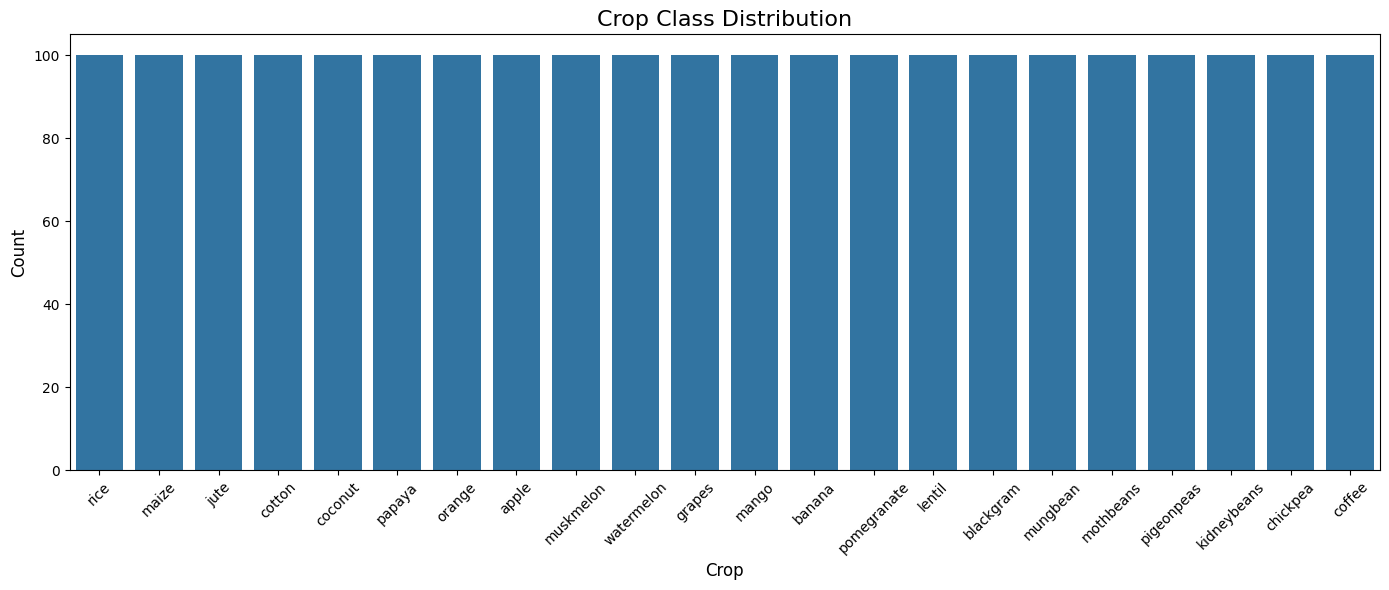

In [10]:
# Bar plot of crop distribution
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.title('Crop Class Distribution', fontsize=16)
plt.xlabel('Crop', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../notebooks/class_distribution.png', dpi=100)
plt.show()

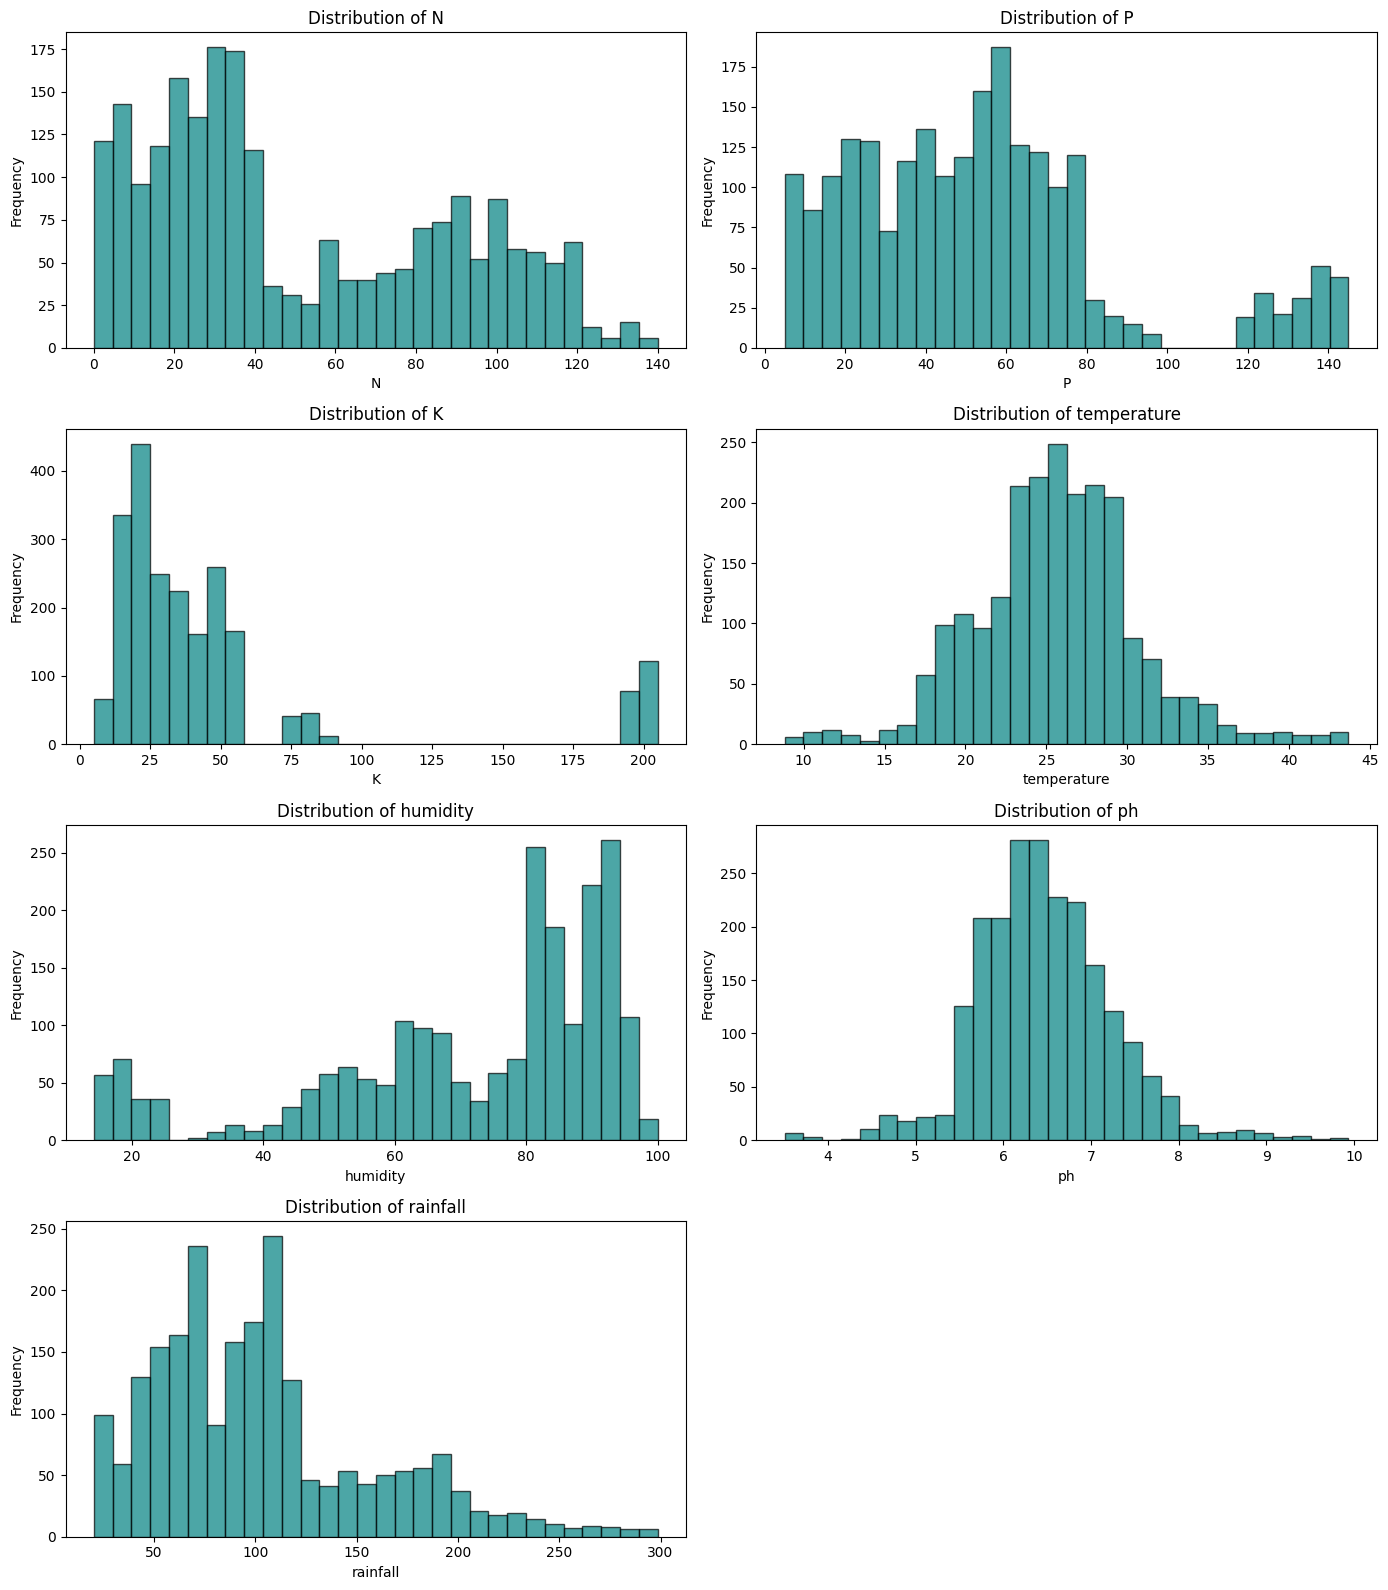

In [11]:
# Histogram for each numerical feature
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df[feature], bins=30, color='teal', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {feature}', fontsize=12)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

# Remove the last empty subplot
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('../notebooks/feature_distributions.png', dpi=100)
plt.show()

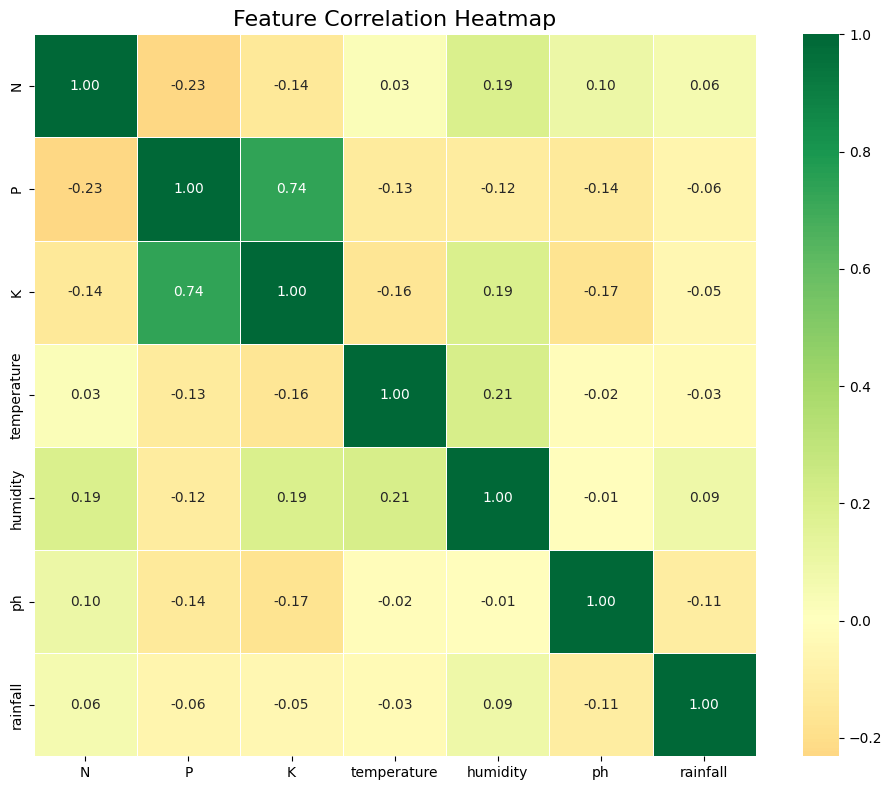

In [12]:
# Correlation matrix
plt.figure(figsize=(10, 8))
corr = df[features].corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('../notebooks/correlation_heatmap.png', dpi=100)
plt.show()

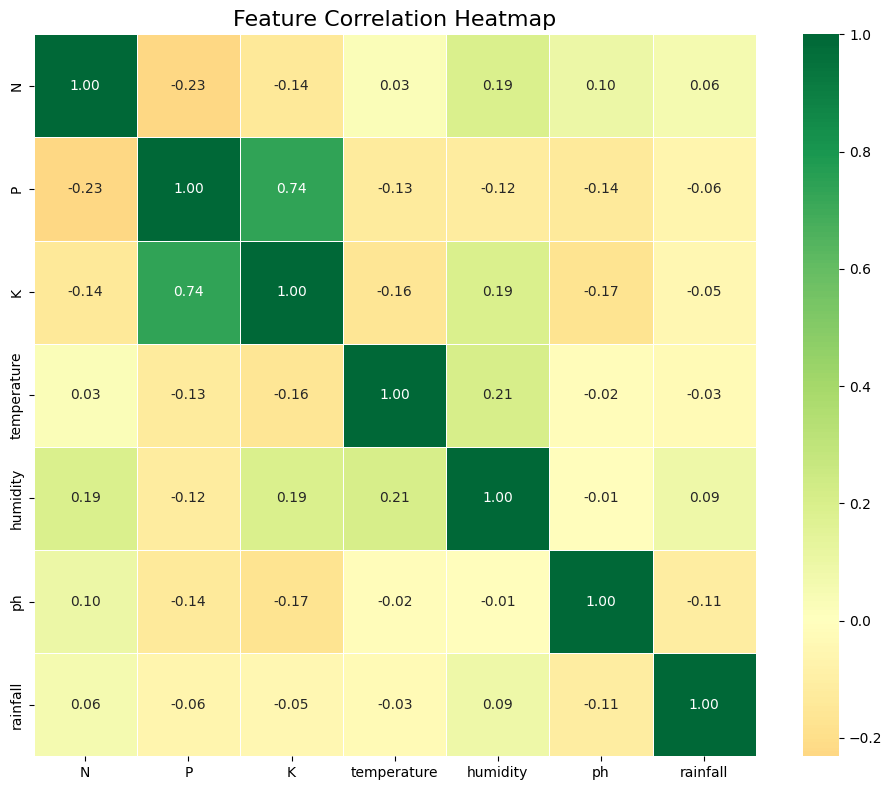

In [13]:
# Correlation matrix
plt.figure(figsize=(10, 8))
corr = df[features].corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('../notebooks/correlation_heatmap.png', dpi=100)
plt.show()

In [14]:
# Step 1: Check and remove duplicates (if any)
print(f"Rows before cleaning: {len(df)}")
df = df.drop_duplicates()
print(f"Rows after removing duplicates: {len(df)}")

# Step 2: Check and handle missing values (if any)
if df.isnull().sum().sum() > 0:
    print("Missing values found. Filling with median...")
    for col in features:
        df[col] = df[col].fillna(df[col].median())
else:
    print("No missing values found. Dataset is clean!")

# Step 3: Verify column names are consistent
print(f"\nFinal columns: {list(df.columns)}")
print(f"Final shape: {df.shape}")

Rows before cleaning: 2200
Rows after removing duplicates: 2200
No missing values found. Dataset is clean!

Final columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']
Final shape: (2200, 8)


In [15]:
# Features = all columns except 'label'
# Target = 'label' column

X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")
print(f"\nUnique target classes: {y.nunique()}")

Features shape: (2200, 7)
Target shape: (2200,)

Feature columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

Unique target classes: 22


In [16]:
from sklearn.model_selection import train_test_split

# 80% training, 20% testing
# stratify=y ensures each crop class is proportionally represented
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining set crop distribution:")
print(y_train.value_counts())

Training set size: 1760
Testing set size: 440

Training set crop distribution:
label
orange         80
grapes         80
coconut        80
papaya         80
pomegranate    80
mango          80
jute           80
watermelon     80
rice           80
maize          80
pigeonpeas     80
blackgram      80
apple          80
muskmelon      80
coffee         80
mungbean       80
lentil         80
banana         80
cotton         80
mothbeans      80
kidneybeans    80
chickpea       80
Name: count, dtype: int64


Minimum samples per class: 100
Maximum samples per class: 100
Balance ratio: 1.00

✅ Dataset is WELL BALANCED. No oversampling/undersampling needed.


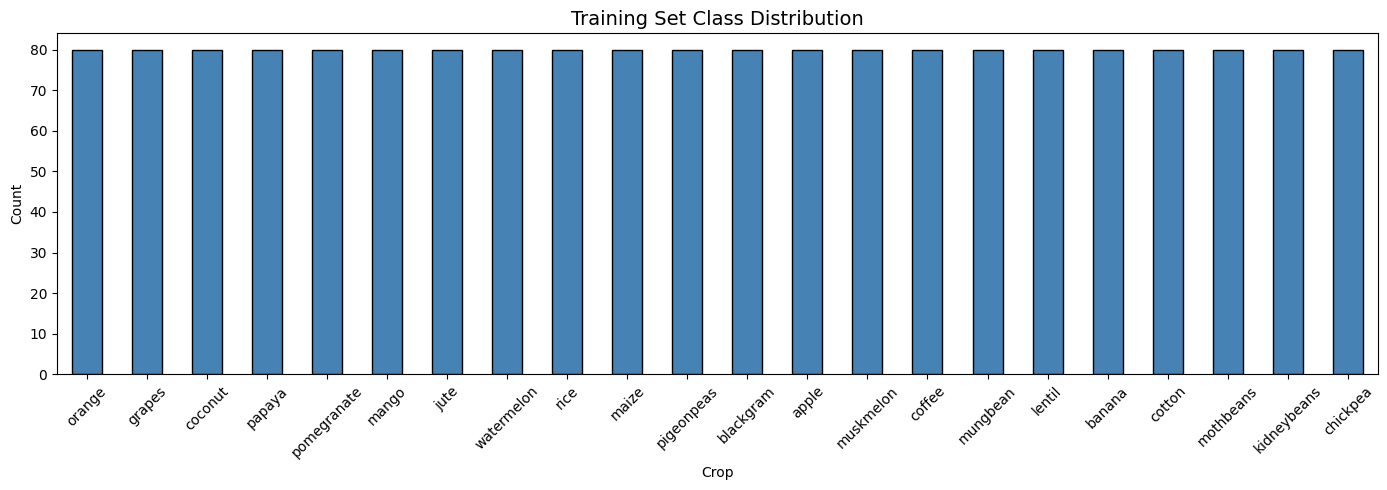

In [17]:
# A dataset is balanced if each class has approximately the same number of samples
class_counts = y.value_counts()
min_count = class_counts.min()
max_count = class_counts.max()
balance_ratio = min_count / max_count

print(f"Minimum samples per class: {min_count}")
print(f"Maximum samples per class: {max_count}")
print(f"Balance ratio: {balance_ratio:.2f}")

if balance_ratio >= 0.8:
    print("\n✅ Dataset is WELL BALANCED. No oversampling/undersampling needed.")
else:
    print("\n⚠️ Dataset is IMBALANCED. Consider resampling techniques.")

# Visualize
plt.figure(figsize=(14, 5))
y_train.value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Training Set Class Distribution', fontsize=14)
plt.xlabel('Crop')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
from sklearn.preprocessing import StandardScaler

# We scale features so all have mean=0 and std=1
# This helps models like Logistic Regression perform better
# Tree-based models (Random Forest, XGBoost) don't need scaling,
# but it doesn't hurt them either

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("Scaled training data (first 5 rows):")
X_train_scaled.head()

Scaled training data (first 5 rows):


,N,P,K,temperature,humidity,ph,rainfall
1607,-1.371628,-1.072910,-0.673510,0.819481,0.924395,0.937545,0.199440
1212,-1.127411,2.084513,3.015261,0.783251,0.426613,-1.153846,-0.643677
362,-1.073140,0.536162,-0.476250,-0.879968,-2.186291,-1.107452,0.694001
566,-0.340487,-0.465713,-0.594606,0.138043,-0.459237,-0.229482,-1.231744
1671,-0.883193,-1.255069,-0.791866,-2.563232,0.915842,-0.341959,0.289941


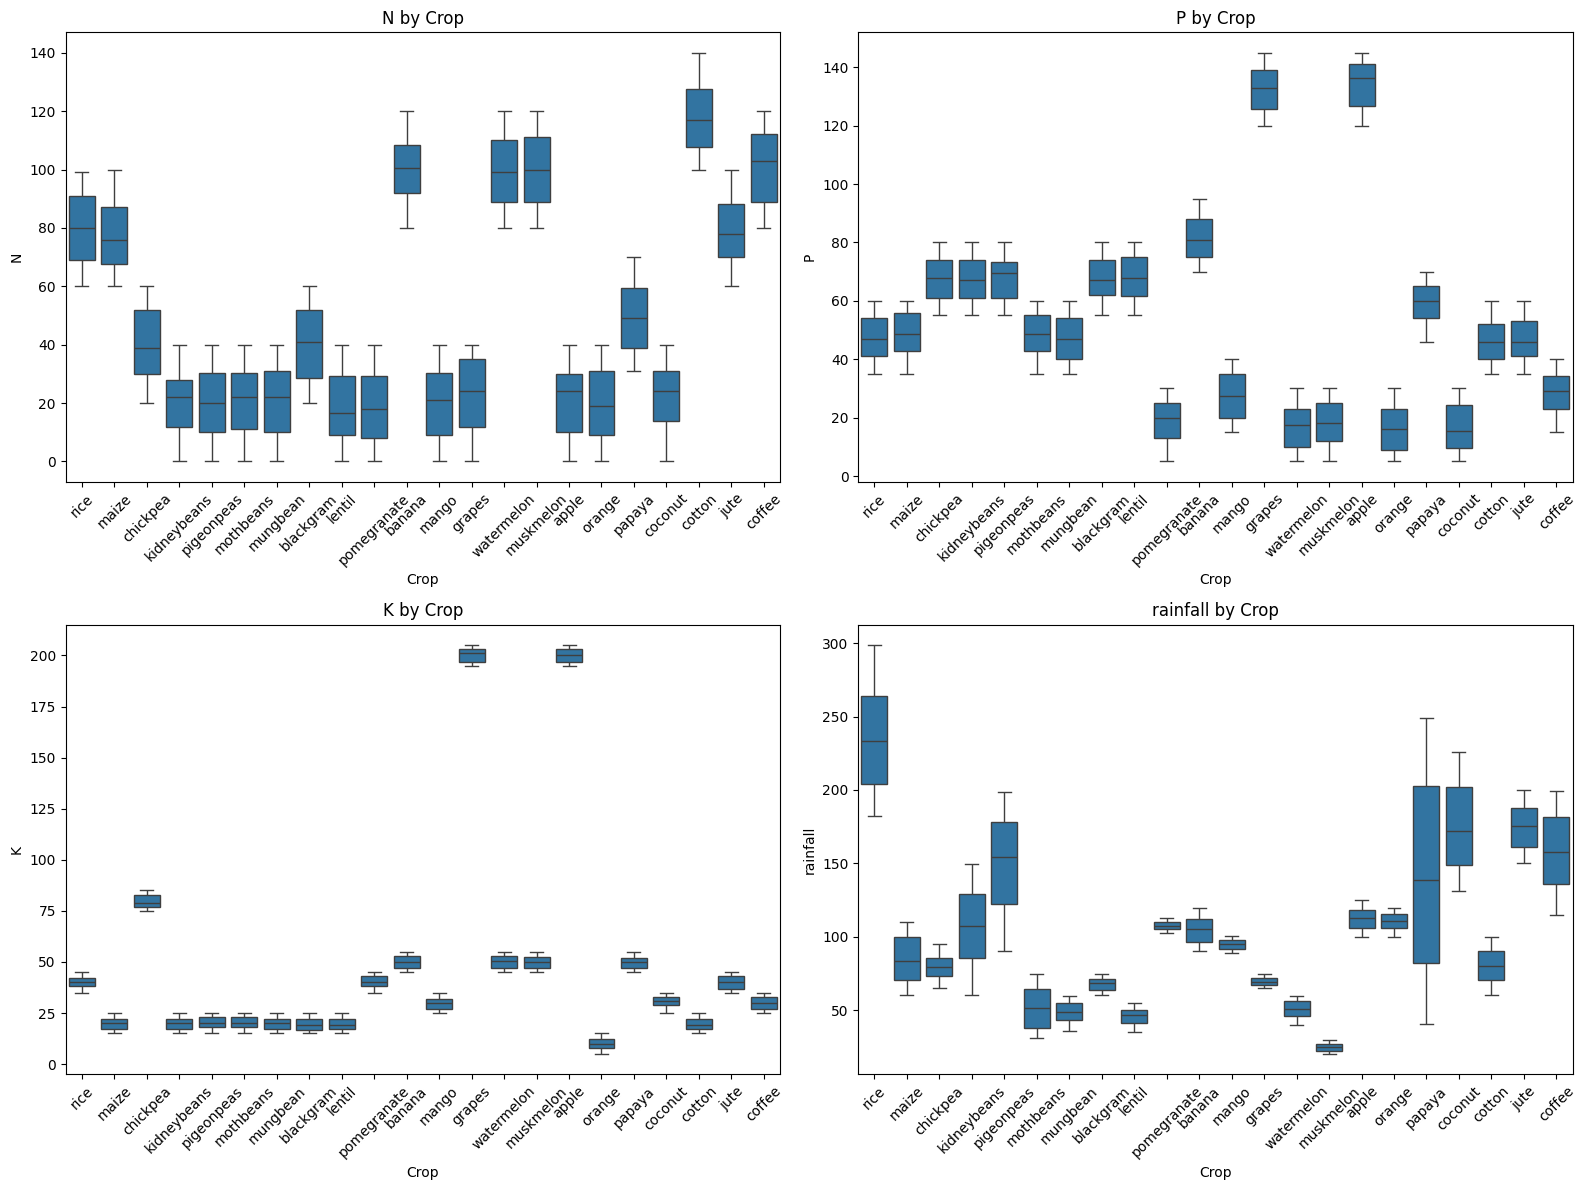

In [19]:
# Boxplots: how each feature varies across different crops
important_features = ['N', 'P', 'K', 'rainfall']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(important_features):
    sns.boxplot(data=df, x='label', y=feature, ax=axes[i])
    axes[i].set_title(f'{feature} by Crop', fontsize=12)
    axes[i].set_xlabel('Crop')
    axes[i].set_ylabel(feature)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../notebooks/boxplots_by_crop.png', dpi=100)
plt.show()

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Try importing XGBoost
try:
    from xgboost import XGBClassifier
    xgboost_available = True
    print("XGBoost is available!")
except ImportError:
    xgboost_available = False
    print("XGBoost not available. Will skip it.")
    print("To install: pip install xgboost")

XGBoost not available. Will skip it.
To install: pip install xgboost


In [21]:
from sklearn.preprocessing import LabelEncoder

# XGBoost requires numeric labels (0, 1, 2, ... not 'rice', 'maize', ...)
# We create a label encoder and also keep it for later use

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("Label encoding mapping:")
for i, crop in enumerate(le.classes_):
    print(f"  {crop} -> {i}")

Label encoding mapping:
  apple -> 0
  banana -> 1
  blackgram -> 2
  chickpea -> 3
  coconut -> 4
  coffee -> 5
  cotton -> 6
  grapes -> 7
  jute -> 8
  kidneybeans -> 9
  lentil -> 10
  maize -> 11
  mango -> 12
  mothbeans -> 13
  mungbean -> 14
  muskmelon -> 15
  orange -> 16
  papaya -> 17
  pigeonpeas -> 18
  pomegranate -> 19
  rice -> 20
  watermelon -> 21


In [22]:
def train_and_evaluate(model, model_name, X_tr, y_tr, X_te, y_te):
    """
    Train a model, make predictions, and print evaluation metrics.
    Returns a dictionary of metrics.
    """
    # Train
    model.fit(X_tr, y_tr)
    
    # Predict
    y_pred = model.predict(X_te)
    
    # Calculate metrics
    accuracy = accuracy_score(y_te, y_pred)
    precision = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    
    # Print results
    print(f"\n{'='*50}")
    print(f"MODEL: {model_name}")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    return {
        'model_name': model_name,
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'y_pred': y_pred
    }

In [23]:
results = []

# ---- Model 1: Logistic Regression ----
lr = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
res_lr = train_and_evaluate(lr, "Logistic Regression",
                            X_train_scaled, y_train, X_test_scaled, y_test)
results.append(res_lr)

# ---- Model 2: Decision Tree ----
dt = DecisionTreeClassifier(random_state=42, max_depth=10)
res_dt = train_and_evaluate(dt, "Decision Tree",
                            X_train, y_train, X_test, y_test)
results.append(res_dt)

# ---- Model 3: Random Forest ----
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
res_rf = train_and_evaluate(rf, "Random Forest",
                            X_train, y_train, X_test, y_test)
results.append(res_rf)

# ---- Model 4: XGBoost (if available) ----
if xgboost_available:
    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss'
    )
    res_xgb = train_and_evaluate(xgb, "XGBoost",
                                 X_train, y_train_encoded, X_test, y_test_encoded)
    # XGBoost predictions are encoded, convert back for comparison
    res_xgb['y_pred'] = le.inverse_transform(res_xgb['y_pred'])
    results.append(res_xgb)


MODEL: Logistic Regression
Accuracy:  0.9727
Precision: 0.9740
Recall:    0.9727
F1-Score:  0.9725

MODEL: Decision Tree
Accuracy:  0.9636
Precision: 0.9718
Recall:    0.9636
F1-Score:  0.9639

MODEL: Random Forest
Accuracy:  0.9955
Precision: 0.9957
Recall:    0.9955
F1-Score:  0.9955


MODEL COMPARISON (sorted by F1-Score):
              Model  Accuracy  Precision   Recall  F1-Score
      Random Forest  0.995455   0.995671 0.995455  0.995452
Logistic Regression  0.972727   0.974022 0.972727  0.972464
      Decision Tree  0.963636   0.971784 0.963636  0.963896


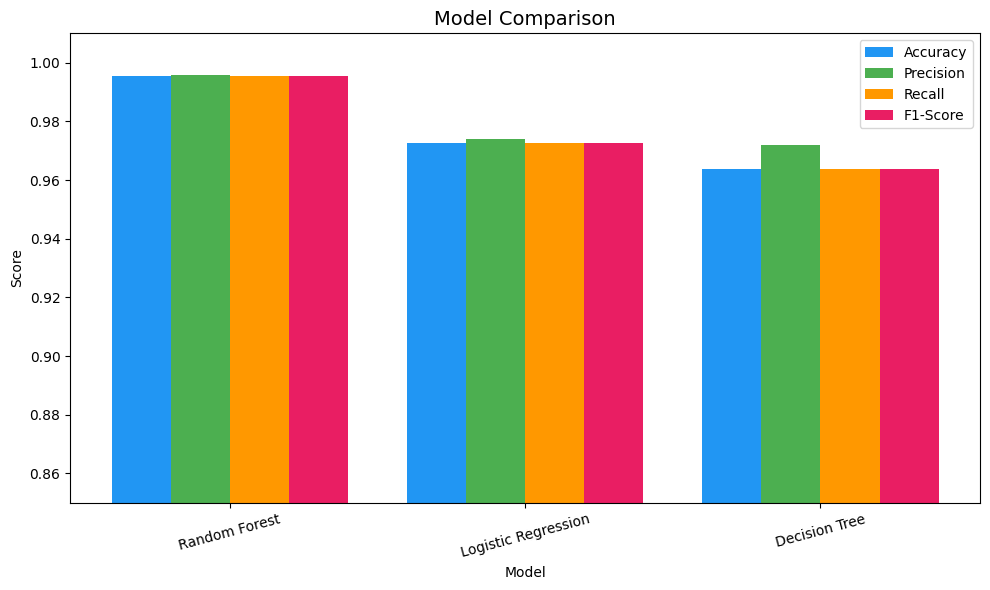

In [24]:
# Create a comparison DataFrame
comparison_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score']
} for r in results])

comparison_df = comparison_df.sort_values('F1-Score', ascending=False)
print("MODEL COMPARISON (sorted by F1-Score):")
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df))
width = 0.2

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, metric in enumerate(metrics):
    ax.bar(x + i*width, comparison_df[metric], width, label=metric, color=colors[i])

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison', fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df['Model'], rotation=15)
ax.set_ylim(0.85, 1.01)
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/model_comparison.png', dpi=100)
plt.show()

🏆 BEST MODEL: Random Forest
   F1-Score: 0.9955
   Accuracy: 0.9955


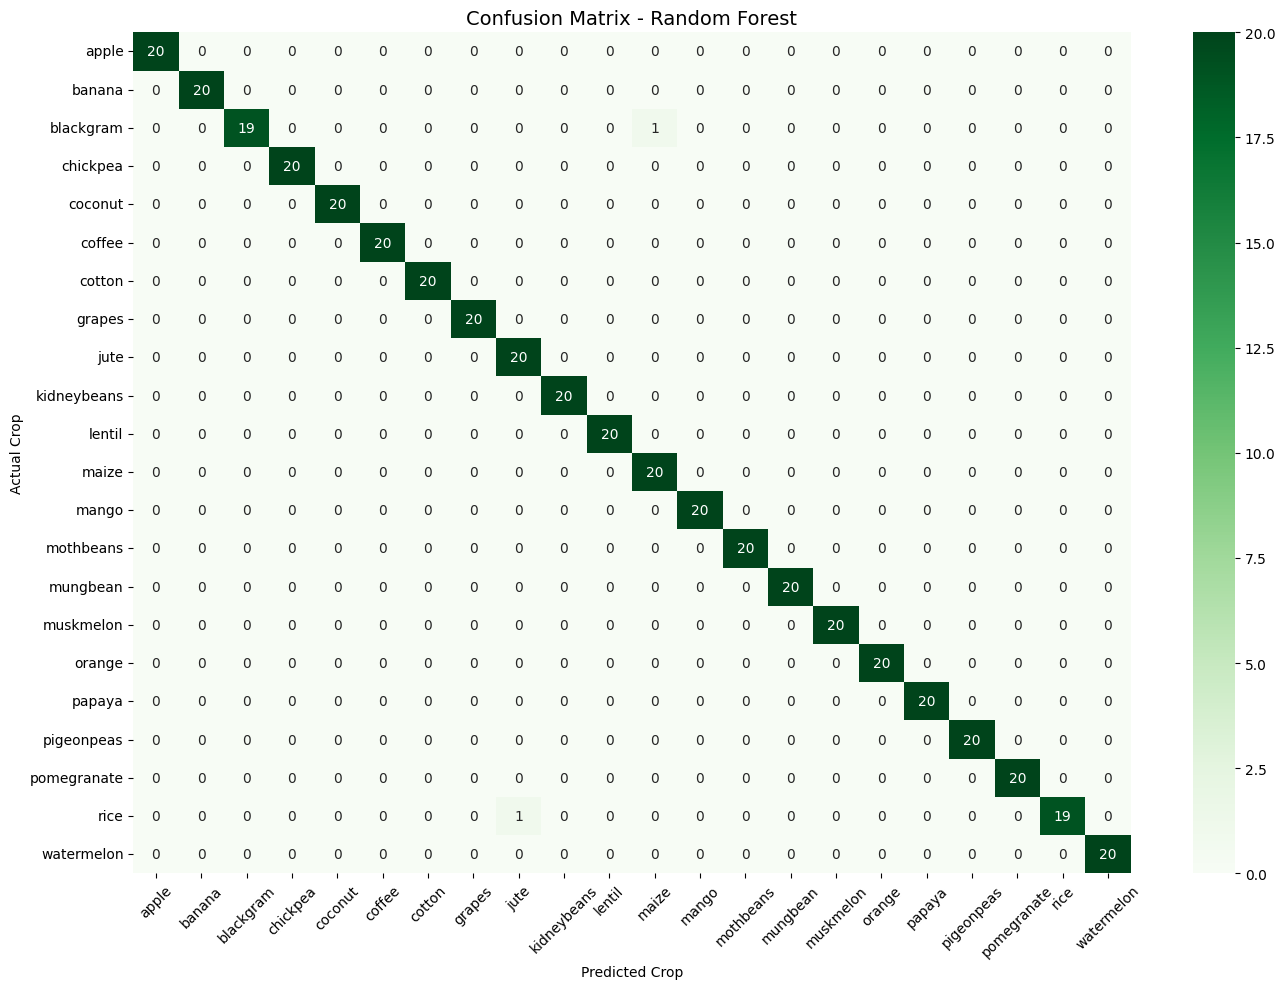

In [25]:
# Select the best model
best_result = max(results, key=lambda r: r['f1_score'])
best_model = best_result['model']
best_model_name = best_result['model_name']

print(f"🏆 BEST MODEL: {best_model_name}")
print(f"   F1-Score: {best_result['f1_score']:.4f}")
print(f"   Accuracy: {best_result['accuracy']:.4f}")

# Confusion Matrix
y_pred_best = best_result['y_pred']
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()))
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14)
plt.xlabel('Predicted Crop')
plt.ylabel('Actual Crop')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../notebooks/confusion_matrix.png', dpi=100)
plt.show()

In [26]:
print(f"\nClassification Report for {best_model_name}:")
print(classification_report(y_test, y_pred_best))


Classification Report for Random Forest:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      

In [27]:
from sklearn.model_selection import GridSearchCV

# We'll tune Random Forest (likely the best)
# If another model won, adjust accordingly

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("Starting Grid Search for Random Forest tuning...")
print("This may take a few minutes...\n")

rf_tuned = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    rf_tuned, param_grid,
    cv=5, scoring='f1_weighted',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

Starting Grid Search for Random Forest tuning...
This may take a few minutes...

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1-Score: 0.9960


In [28]:
# Train the final model with best parameters
final_model = grid_search.best_estimator_
y_pred_final = final_model.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final, average='weighted')
final_precision = precision_score(y_test, y_pred_final, average='weighted', zero_division=0)
final_recall = recall_score(y_test, y_pred_final, average='weighted', zero_division=0)

print("FINAL TUNED MODEL PERFORMANCE:")
print(f"  Accuracy:  {final_accuracy:.4f}")
print(f"  Precision: {final_precision:.4f}")
print(f"  Recall:    {final_recall:.4f}")
print(f"  F1-Score:  {final_f1:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_final))

FINAL TUNED MODEL PERFORMANCE:
  Accuracy:  0.9955
  Precision: 0.9957
  Recall:    0.9955
  F1-Score:  0.9955

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20


In [29]:
# Test 1: Conditions good for rice (high rainfall, high humidity)
test1 = pd.DataFrame([{
    'N': 90, 'P': 42, 'K': 43,
    'temperature': 25.5, 'humidity': 80.0,
    'ph': 6.5, 'rainfall': 200.0
}])
pred1 = final_model.predict(test1)[0]
print(f"Test 1 - Expected: rice,  Predicted: {pred1}")

# Test 2: Conditions good for maize
test2 = pd.DataFrame([{
    'N': 80, 'P': 50, 'K': 40,
    'temperature': 28.0, 'humidity': 65.0,
    'ph': 6.0, 'rainfall': 120.0
}])
pred2 = final_model.predict(test2)[0]
print(f"Test 2 - Expected: maize, Predicted: {pred2}")

# Test 3: Conditions good for apple (cool, moderate rain)
test3 = pd.DataFrame([{
    'N': 20, 'P': 130, 'K': 200,
    'temperature': 18.0, 'humidity': 85.0,
    'ph': 6.5, 'rainfall': 100.0
}])
pred3 = final_model.predict(test3)[0]
print(f"Test 3 - Expected: apple, Predicted: {pred3}")

# Test 4: Conditions good for chickpea
test4 = pd.DataFrame([{
    'N': 40, 'P': 60, 'K': 30,
    'temperature': 25.0, 'humidity': 35.0,
    'ph': 7.0, 'rainfall': 40.0
}])
pred4 = final_model.predict(test4)[0]
print(f"Test 4 - Expected: chickpea, Predicted: {pred4}")

Test 1 - Expected: rice,  Predicted: rice
Test 2 - Expected: maize, Predicted: coffee
Test 3 - Expected: apple, Predicted: grapes
Test 4 - Expected: chickpea, Predicted: mothbeans


In [30]:
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    """
    Predict the recommended crop based on soil and weather conditions.
    
    Parameters:
        N (float): Nitrogen content (kg/ha)
        P (float): Phosphorus content (kg/ha)
        K (float): Potassium content (kg/ha)
        temperature (float): Temperature in °C
        humidity (float): Relative humidity in %
        ph (float): Soil pH
        rainfall (float): Rainfall in mm
    
    Returns:
        str: Recommended crop name
    """
    # Create input DataFrame with same column names
    input_data = pd.DataFrame([{
        'N': N,
        'P': P,
        'K': K,
        'temperature': temperature,
        'humidity': humidity,
        'ph': ph,
        'rainfall': rainfall
    }])
    
    # Predict using the final model
    prediction = final_model.predict(input_data)[0]
    
    return prediction

# Test the function
result = predict_crop(90, 42, 43, 25.5, 80.0, 6.5, 200.0)
print(f"Recommended crop: {result}")

Recommended crop: rice


In [31]:
import joblib
import os

# Ensure directories exist
os.makedirs('../backend/models', exist_ok=True)
os.makedirs('../backend/scalers', exist_ok=True)
os.makedirs('../backend/encoders', exist_ok=True)

# Save the trained model
joblib.dump(final_model, '../backend/models/crop_model.pkl')
print("✅ Model saved to backend/models/crop_model.pkl")

# Save the scaler (for Logistic Regression if needed later)
joblib.dump(scaler, '../backend/scalers/crop_scaler.pkl')
print("✅ Scaler saved to backend/scalers/crop_scaler.pkl")

# Save the label encoder (for XGBoost decoding if needed later)
joblib.dump(le, '../backend/encoders/label_encoder.pkl')
print("✅ Label encoder saved to backend/encoders/label_encoder.pkl")

# Verify saved files
print(f"\nModel file size: {os.path.getsize('../backend/models/crop_model.pkl') / 1024:.1f} KB")

✅ Model saved to backend/models/crop_model.pkl
✅ Scaler saved to backend/scalers/crop_scaler.pkl
✅ Label encoder saved to backend/encoders/label_encoder.pkl

Model file size: 2636.3 KB


In [32]:
# Load the model back and test
loaded_model = joblib.load('../backend/models/crop_model.pkl')

test_result = loaded_model.predict(pd.DataFrame([{
    'N': 90, 'P': 42, 'K': 43,
    'temperature': 25.5, 'humidity': 80.0,
    'ph': 6.5, 'rainfall': 200.0
}]))[0]

print(f"Loaded model prediction: {test_result}")
print("✅ Saved model works correctly!")

Loaded model prediction: rice
✅ Saved model works correctly!
